Dataset Shape: (10000, 12)
Type of ML Problem: Classification (because target 'churn' is binary: 0 or 1)
Shape of X: (10000, 11)
Shape of y: (10000,)
Categorical Columns: Index(['country', 'gender'], dtype='object')


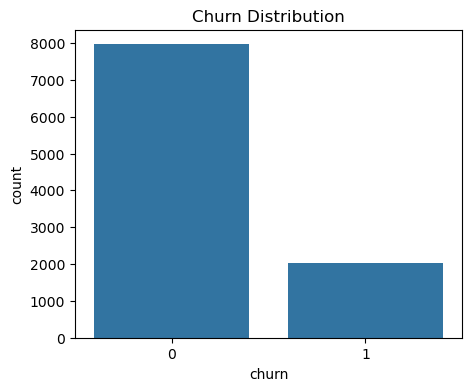

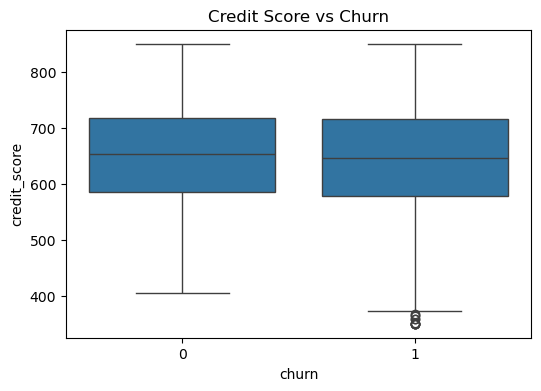

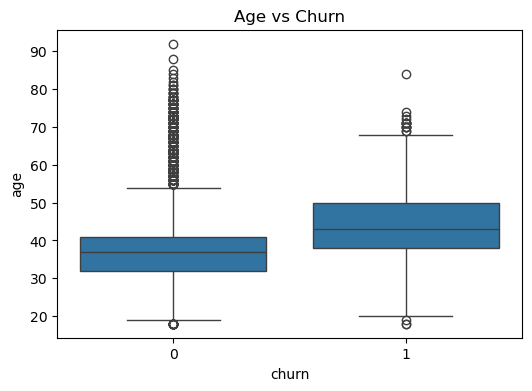

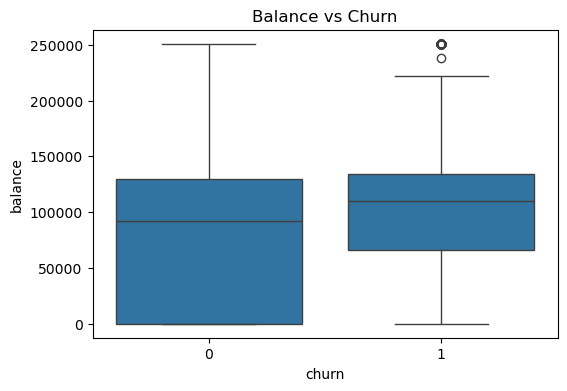


===== SVM Results =====
Accuracy: 0.8525
Confusion Matrix:
 [[1565   42]
 [ 253  140]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.97      0.91      1607
           1       0.77      0.36      0.49       393

    accuracy                           0.85      2000
   macro avg       0.82      0.67      0.70      2000
weighted avg       0.84      0.85      0.83      2000


===== Random Forest Results =====
Accuracy: 0.8535
Confusion Matrix:
 [[1543   64]
 [ 229  164]]
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.96      0.91      1607
           1       0.72      0.42      0.53       393

    accuracy                           0.85      2000
   macro avg       0.80      0.69      0.72      2000
weighted avg       0.84      0.85      0.84      2000



In [2]:
# ===============================
# Q1. Load Data & Identify Problem
# ===============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load cleaned dataset
df = pd.read_csv(r"C:\Users\MAHESHWARI\OneDrive\Documents\Customer_Chrun_clean_data.csv")  # change file name if needed

print("Dataset Shape:", df.shape)

# ML Problem Type
print("Type of ML Problem: Classification (because target 'churn' is binary: 0 or 1)")

# Define Features and Target
X = df.drop("churn", axis=1)
y = df["churn"]

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)


# ===============================
# Q2. Encoding & Scaling
# ===============================

# Identify categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns
print("Categorical Columns:", categorical_cols)

# Apply One-Hot Encoding
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Standard Scaling for numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# ===============================
# Q3. EDA - Churn Distribution & Relationships
# ===============================

# Churn Distribution
plt.figure(figsize=(5,4))
sns.countplot(x=df["churn"])
plt.title("Churn Distribution")
plt.show()

# CreditScore vs Churn
plt.figure(figsize=(6,4))
sns.boxplot(x="churn", y="credit_score", data=df)
plt.title("Credit Score vs Churn")
plt.show()

# Age vs Churn
plt.figure(figsize=(6,4))
sns.boxplot(x="churn", y="age", data=df)
plt.title("Age vs Churn")
plt.show()

# Balance vs Churn
plt.figure(figsize=(6,4))
sns.boxplot(x="churn", y="balance", data=df)
plt.title("Balance vs Churn")
plt.show()


# ===============================
# Q4. Train SVM Model
# ===============================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

svm_model = SVC()
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("\n===== SVM Results =====")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("Classification Report:\n", classification_report(y_test, y_pred_svm))


# ===============================
# Q5. Train Random Forest
# ===============================

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("\n===== Random Forest Results =====")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))